# Detección de fuego y humo con redes neuronales convolucionales

**Proyecto Final de Ingeniería en Electrónica — FaCENA-UNNE**
(Red de sensores LoRa para detección temprana de incendios)

Entrenamos una **CNN** en TensorFlow/Keras que da, para cada imagen, **dos
probabilidades independientes**:

| Salida | Qué mide |
|---|---|
| P(`fuego`) | hay llamas visibles, haya o no humo |
| P(`humo`) | hay humo, haya o no llamas |

No son clases excluyentes: el 80 % de las imágenes con fuego también tiene humo, así que
una escena puede tener las dos (`fuego+humo`), una sola, o ninguna (`nada`).

El dataset es **D-Fire** (`sayedgamal99/smoke-fire-detection-yolo` de Kaggle, 21527
imágenes JPEG), un banco de *detección* (bounding boxes YOLO: `0` = humo, `1` = fuego)
del que derivamos la etiqueta a nivel imagen (ver §2).

> **Base de este notebook.** Es una adaptación del notebook de clasificación de tumores
> cerebrales en MRI: mismo pipeline `tf.data`, mismo régimen de entrenamiento
> (AdamW + EMA, EarlyStopping, ReduceLROnPlateau) y misma estructura de evaluación
> (matriz de confusión, Grad-CAM). Cambia lo que depende del problema: dataset D-Fire en
> lugar de BRISC2025, imágenes **RGB a color** (el color es la señal del fuego) en vez de
> escala de grises, etiquetas derivadas de anotaciones YOLO y **2 etiquetas
> independientes** (sigmoides) de salida en lugar de 4 clases excluyentes.
>
> **La arquitectura ya NO es la CNN de cuatro bloques** de aquel notebook: el modelo
> tiene que correr en el nodo ESP32-S3 y aquella red (1,1 M de parámetros, 845 MMAC)
> tardaba ~8 s por inferencia, así que no era desplegable. Se usa **MobileNetV1 α=0.25**
> preentrenada en ImageNet (§4); la cuantización y la exportación a **TFLite Micro
> int8** están en `5_cuantizacion.ipynb`.

**Recorrido:** exploración de datos → pipeline `tf.data` → arquitectura y costo en el
nodo → entrenamiento → evaluación float → Grad-CAM → modelo entrenado (`.keras`). La
cuantización a int8, la evaluación del modelo cuantizado "como lo ve la cámara", el
umbral de decisión y los archivos para el firmware siguen en `5_cuantizacion.ipynb`.

Link del dataset: https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo


## 0. Descarga del dataset

Descargamos **D-Fire** en formato YOLO (bounding boxes para humo y fuego) desde
Kaggle: [`sayedgamal99/smoke-fire-detection-yolo`](https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo).
Con `KAGGLEHUB_CACHE` apuntando a `data/` del proyecto, el dataset queda dentro del
proyecto (no en `~/.cache/kagglehub`), y la celda es **idempotente**: la segunda
corrida no vuelve a descargar.
Requiere credencial de Kaggle en `~/.kaggle/kaggle.json` o las variables de
entorno `KAGGLE_USERNAME` / `KAGGLE_KEY`.

In [ ]:
from pathlib import Path
import os

# El kernel puede arrancar en la raíz del proyecto o en `notebooks/`: resolvemos
# `data/` de forma robusta en ambos casos.
RAIZ = Path("data") if Path("data").exists() else Path("../data")
RAIZ = RAIZ.resolve()

# `kagglehub` descarga donde diga KAGGLEHUB_CACHE: hay que setearlo ANTES de
# importarlo para que el dataset quede en `data/` del proyecto y no en
# ~/.cache/kagglehub.
os.environ["KAGGLEHUB_CACHE"] = str(RAIZ)
import kagglehub

# Si el dataset ya está descargado, devuelve la ruta y no vuelve a bajarlo.
DATASET_DIR = Path(kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo"))
print("Dataset en:", DATASET_DIR)
for ruta in sorted(DATASET_DIR.iterdir()):
    print(" ", ruta.name)
    if ruta.is_dir():
        print("   ", sorted(s.name for s in ruta.iterdir()))

## 1. Configuración del entorno

Antes de importar TensorFlow precargamos las librerías CUDA. Los *wheels* de TF 2.21
no registran correctamente las rutas de los paquetes `nvidia-*` instalados por pip, así
que las cargamos a mano; sin esto TF cae a CPU silenciosamente.

Y un detalle que cuesta una noche de trabajo si no se sabe: TF 2.21 arrastra
**cuDNN 9.26, que ya no trae kernels para Pascal**. En una GTX 1050 (sm_6.1) la
primera convolución muere con `No algorithm worked! ... cudnn status: 5003` — no es
falta de memoria, es que no existe el kernel. `pyproject.toml` fija
`nvidia-cudnn-cu12==9.8.0.87`, la última que sí compila para esa arquitectura;
verificado en esta máquina. La sonda de abajo es la red de seguridad: si igual no hay
convolución posible en la GPU, esconde el dispositivo y se entrena en CPU en vez de
reventar veinte celdas más adelante.

In [2]:
# Precarga de librerías CUDA (debe ejecutarse ANTES de importar tensorflow)
import ctypes
import glob
import os
import site
import subprocess
import sys

for _lib in glob.glob(os.path.join(site.getsitepackages()[0], "nvidia", "*", "lib", "*.so*")):
    try:
        ctypes.CDLL(_lib, mode=ctypes.RTLD_GLOBAL)
    except OSError:
        pass

# Sonda de GPU en un subproceso: cuDNN 9.26 (el que trae TF 2.21) ya no tiene
# kernels para Pascal (sm_6.1, la GTX 1050 de esta máquina), así que la primera
# convolución muere con "No algorithm worked!". Averiguarlo acá y caer a CPU es
# más barato que descubrirlo recién en `fit`. Va en un subproceso porque
# `set_visible_devices` no se puede llamar después de inicializar el contexto.
_SONDA = (
    "import ctypes,glob,os,site\n"
    "[ctypes.CDLL(l, mode=ctypes.RTLD_GLOBAL) for l in "
    "glob.glob(os.path.join(site.getsitepackages()[0],'nvidia','*','lib','*.so*'))"
    " if os.path.exists(l)]\n"
    "import tensorflow as tf\n"
    "assert tf.config.list_physical_devices('GPU')\n"
    "with tf.device('/GPU:0'):\n"
    "    tf.nn.conv2d(tf.zeros([1,32,32,3]), tf.zeros([3,3,3,8]), 1, 'SAME').numpy()\n"
)
_sonda = subprocess.run([sys.executable, "-c", _SONDA], capture_output=True,
                        env={**os.environ, "TF_CPP_MIN_LOG_LEVEL": "3"})
GPU_USABLE = _sonda.returncode == 0
if not GPU_USABLE:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    print("GPU descartada, se entrena en CPU. Motivo:")
    print("  " + (_sonda.stderr.decode().strip().splitlines() or ["sin GPU"])[-1][:160])
else:
    print("GPU utilizable para convoluciones.")


GPU utilizable para convoluciones.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42                             # Semilla para reproducibilidad
keras.utils.set_random_seed(SEED)

# `memory_growth` evita que TF reserve toda la VRAM de entrada: útil en GPUs chicas.
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Dispositivos:", tf.config.list_physical_devices())

I0000 00:00:1789993701.418229   21845 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
Keras: 3.15.1
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Exploración del dataset

D-Fire es un banco de *detección*: cada imagen trae un `.txt` con cajas YOLO
(`0` = humo, `1` = fuego; archivo vacío = fondo, sin objetos). Para clasificar a nivel
imagen derivamos **dos etiquetas binarias** por archivo:

- `fuego` = 1 si hay al menos una caja de clase `1`
- `humo` = 1 si hay al menos una caja de clase `0`

Las dos pueden valer 1 a la vez. Al principio este notebook usaba tres clases
excluyentes (`fuego` / `humo` / `nada`) y metía toda escena con llama en `fuego`; pero el
80 % de esas escenas también tiene humo, así que la salida `humo` terminaba significando
"humo **sin** fuego" y la probabilidad de humo de una escena con llama salía cero por
construcción. Con dos etiquetas independientes, las cuatro combinaciones (`nada`, `humo`,
`fuego`, `fuego+humo`) quedan representadas. La lógica está en `modulos/dfire.py`,
compartida con el notebook de cuantización.

Recorremos los tres splits que trae el banco (`train`/`val`/`test`) y **conservamos a
cuál pertenece cada imagen**: se usa esa partición tal cual, no una nueva (§3). Armamos
de una vez el índice de rutas, etiquetas y split: lo vamos a reutilizar para el pipeline
y para la evaluación.

In [4]:
# Etiquetas, partición y lectura de imágenes viven en `modulos/dfire.py`: el notebook de
# cuantización (5) tiene que preprocesar EXACTAMENTE igual que acá, y una sola
# definición importada por los dos lo garantiza.
import sys

MODULOS = Path("../modulos") if Path("../modulos").exists() else Path("modulos")
SALIDAS = MODULOS.parent / "salidas"        # misma raíz que `modulos/`
sys.path.insert(0, str(MODULOS.resolve()))
from dfire import CLASES, COMBOS, combo, indexar

DATA_DIR = RAIZ / "datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data"

# `indexar` conserva de qué split oficial vino cada imagen: D-Fire son frames de video
# y rearmar la partición al azar dejaría cuadros casi idénticos de un mismo incendio
# en train y en test. La partición que trae el banco ya evita eso.
ARCHIVOS, ETIQUETAS, SPLITS = indexar(DATA_DIR)     # ETIQUETAS: (N, 2) [fuego, humo]
COMBO = combo(ETIQUETAS)
conteos = np.bincount(COMBO, minlength=len(COMBOS))

for i, nombre in enumerate(COMBOS):
    print(f"{nombre:<11} {conteos[i]:>6}  ({100 * conteos[i] / len(COMBO):5.1f} %)")
print(f"{'TOTAL':<11} {len(COMBO):>6}")
print(f"\n{100 * conteos[3] / (conteos[2] + conteos[3]):.0f} % de las imágenes con fuego "
      f"también tiene humo: por eso las etiquetas no pueden ser clases excluyentes.")

nada          9838  ( 45.7 %)
humo          5867  ( 27.3 %)
fuego         1164  (  5.4 %)
fuego+humo    4658  ( 21.6 %)
TOTAL        21527

80 % de las imágenes con fuego también tiene humo: por eso las etiquetas no pueden ser clases excluyentes.


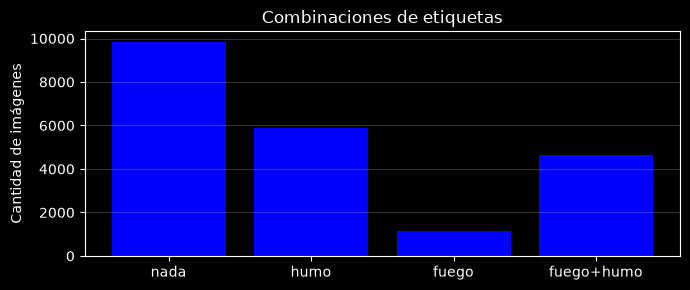

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(COMBOS, conteos, color="blue")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Combinaciones de etiquetas")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

Miramos una muestra de cada clase. Son fotos a color de escenas variadas —interiores,
rutas, campos, de día y de noche— en tamaños dispares, por lo que habrá que llevarlas
todas a una resolución común. Esa variedad de encuadres e iluminación es lo que el
aumento de datos tiene que absorber para que la red no memorice fondos.

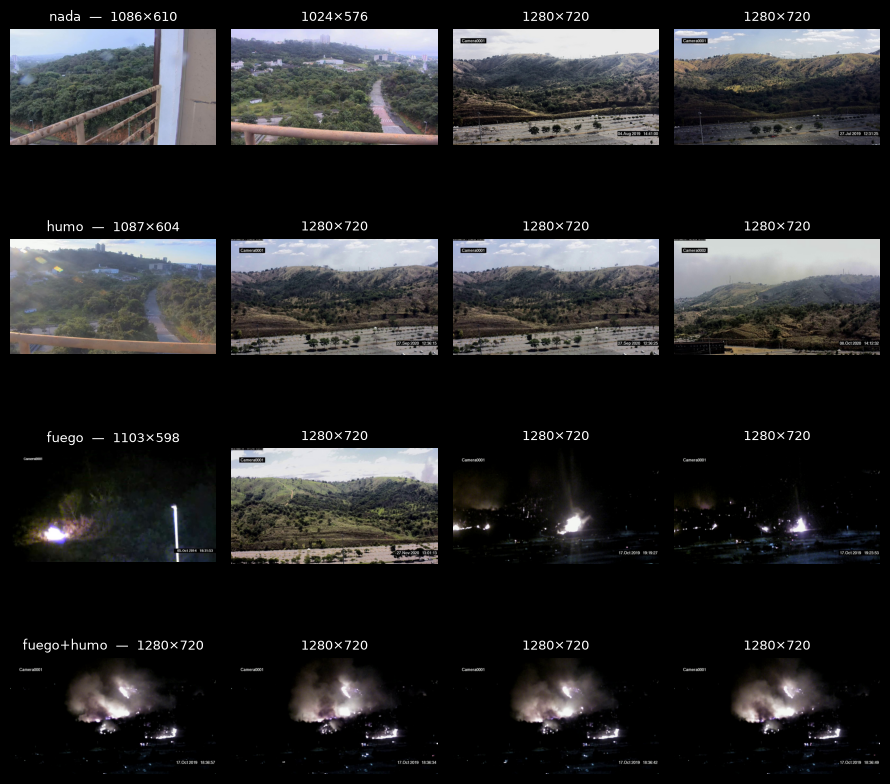

In [6]:
fig, axes = plt.subplots(len(COMBOS), 4, figsize=(9, 9))
for fila, nombre in enumerate(COMBOS):
    archivos = ARCHIVOS[COMBO == fila][:4]
    for col, archivo in enumerate(archivos):
        img = keras.utils.load_img(archivo)
        axes[fila, col].imshow(img)
        axes[fila, col].axis("off")
        titulo = f"{nombre}  —  " if col == 0 else ""
        axes[fila, col].set_title(f"{titulo}{img.size[0]}×{img.size[1]}", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Pipeline de datos

Decisiones de preprocesamiento:

- **Tamaño 96×96.** Es un `framesize` nativo del OV2640 (`FRAMESIZE_96X96`): el sensor
  entrega el buffer ya del tamaño que come la red y el firmware **no necesita código de
  reescalado**. Eso elimina la clase de error más cara del despliegue: que el resize de
  la placa no coincida con el del entrenamiento (bilineal vs *nearest*, recorte vs
  estirado) y la exactitud se caiga sin que nada falle. 128×128 no es framesize nativo.
- **RGB (3 canales).** El color es LA señal discriminativa: el naranja de la llama y el
  gris del humo no existen en escala de grises. Se conserva la imagen a color tal cual.
- **Partición oficial del banco** (14 122 / 3 099 / 4 306), no una nueva. D-Fire se armó
  en buena medida con cuadros extraídos de video: hay imágenes casi idénticas entre sí.
  Repartir al azar el banco completo manda cuadros hermanos del mismo incendio a
  entrenamiento y a prueba, y el número de prueba deja de medir generalización para medir
  memorización. La partición que trae el banco ya está hecha con ese cuidado, así que
  respetarla es a la vez lo correcto y lo más barato. Sólo desordenamos *dentro* de cada
  split, para que ningún lote quede con una sola clase.
- **Cuánto sobra de todos modos**: ni siquiera la partición oficial queda limpia. Medido
  en §6bis, el **22,9 %** de las imágenes de prueba tiene un gemelo perceptual en
  entrenamiento. Por eso la métrica que vale se informa dos veces: sobre la prueba
  completa y sobre el subconjunto sin gemelos.


In [7]:
from dfire import IMG_SIZE, particion

BATCH_SIZE = 32

# Partición oficial del banco. `particion` sólo desordena DENTRO de cada split: la
# pertenencia no cambia, pero ningún lote queda con una sola clase.
particiones = particion(SPLITS, SEED)
idx_train, idx_val, idx_test = (particiones[s] for s in ("train", "val", "test"))

for nombre, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
    reparto = "  ".join(f"{COMBOS[c]} {np.sum(COMBO[idx] == c)}"
                        for c in range(len(COMBOS)))
    print(f"{nombre:<6} {len(idx):>6} imágenes    {reparto}")

train   14122 imágenes    nada 6458  humo 3836  fuego 770  fuego+humo 3058
val      3099 imágenes    nada 1375  humo 845  fuego 174  fuego+humo 705
test     4306 imágenes    nada 2005  humo 1186  fuego 220  fuego+humo 895


In [8]:
from dfire import armar_ds

# `armar_ds` lee cada imagen con `dfire.leer_imagen` (bilineal con antialias, redondeo a
# uint8), la cachea en RAM y la entrega en lotes float32 0-255: la escala a [-1, 1] está
# adentro del modelo (`Rescaling`, ver §4). El notebook de cuantización arma sus datos
# con la misma función, así que calibración y evaluación int8 ven exactamente lo mismo.
train_ds = armar_ds(ARCHIVOS[idx_train], ETIQUETAS[idx_train], BATCH_SIZE,
                    mezclar=True, seed=SEED)
val_ds = armar_ds(ARCHIVOS[idx_val], ETIQUETAS[idx_val], BATCH_SIZE)
test_ds = armar_ds(ARCHIVOS[idx_test], ETIQUETAS[idx_test], BATCH_SIZE)

# Un lote de entrenamiento tiene que ver varias combinaciones.
_, y0 = next(iter(train_ds))
print(f"combinaciones distintas en el primer lote: {len(np.unique(combo(y0.numpy())))} "
      f"de {len(COMBOS)}")

I0000 00:00:1789993711.085692   21845 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3488 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1


combinaciones distintas en el primer lote: 4 de 4


W0000 00:00:1789993717.829800   21845 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Escala de la entrada

Los píxeles llegan en 0–255. El modelo arranca con `layers.Rescaling(1/127.5, offset=-1)`:
una escala **fija**, sin estadísticas que medir, que deja la entrada en [-1, 1] — que es
exactamente lo que espera MobileNet preentrenada en ImageNet (`preprocess_input` hace eso).

Fija y no adaptada (`layers.Normalization`) por la cuantización. Con una escala conocida,
el converter pliega el `Rescaling` dentro del grafo y deja la entrada del `.tflite` en
`scale = 1`, `zero_point = -128`, o sea que el preprocesamiento en el firmware es una
resta de una constante:

```c
input[i] = pixel[i] - 128;   // píxel 0-255 del OV2640 (uint8) -> int8
```

Con media y varianza medidas, esas constantes salen del dataset de entrenamiento y hay
que replicarlas a mano en el nodo.


### Aumento de datos

Con ~15 mil imágenes de entrenamiento el sobreajuste es el riesgo principal, y hay uno
específico que evitar: como el banco mezcla encuadres, fondos e iluminaciones, la red
podría aprender *dónde* suele aparecer el fuego en el cuadro (o qué fondo lo acompaña)
en lugar de *cómo* se ve. Espejado, rotación, traslación, zoom y contraste generan en
cada época una variante distinta de la misma imagen, así que esas pistas dejan de ser
confiables. Sumamos **brillo aleatorio** (`RandomBrightness`): las escenas de fuego
varían muchísimo en iluminación (día/noche, exposición), y la red no debe depender del
nivel absoluto de luz.

Al final agregamos **borrado aleatorio** (`RandomErasing`): en cada época se tapa un
parche al azar. Como el parche cae en cualquier lado, ninguna región concreta está
siempre disponible, y la red no puede resolver la clase mirando un solo lugar fijo del
cuadro. Es la misma idea que `Dropout`, aplicada a la entrada en vez de a las
activaciones.

Sin relleno negro: las fotos no tienen fondo uniforme, así que rotación, traslación y
zoom usan el modo `reflect` por defecto (las esquinas vacías se espejan en vez de
rellenarse con un color que no existe en la escena).

Las capas de aumento sólo actúan en entrenamiento: en inferencia dejan pasar la imagen
sin tocar.

In [9]:
aumento_datos = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(1 / 12),      # factor en fracciones de 2*pi -> ±30°
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.10),
        # Las escenas de fuego varían mucho en iluminación (día/noche, exposición):
        # el brillo aleatorio evita que la red dependa del nivel absoluto de luz.
        layers.RandomBrightness(0.15),
        # Borrado aleatorio: tapa un parche de la imagen para que la red no pueda
        # apoyarse en una sola región. factor=0.5 -> probabilidad por imagen sorteada
        # en [0, 0.5]; scale es la fracción de área borrada, acotada al 15 % para no
        # tapar el foco de fuego entero y ensuciar la etiqueta.
        layers.RandomErasing(factor=0.5, scale=(0.02, 0.15)),
    ],
    name="aumento_datos",
)

W0000 00:00:1789993720.809475   21845 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


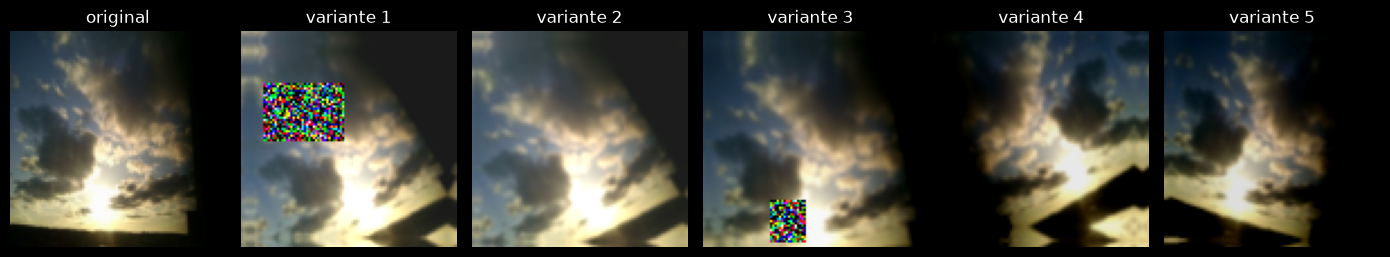

In [10]:
# Efecto del aumento sobre una misma imagen
lote_img, _ = next(iter(train_ds))
original = lote_img[0]

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
axes[0].imshow(original.numpy().astype("uint8"))
axes[0].set_title("original")
axes[0].axis("off")
for i in range(1, 6):
    aumentada = aumento_datos(tf.expand_dims(original, 0), training=True)
    axes[i].imshow(aumentada[0].numpy().astype("uint8"))
    axes[i].set_title(f"variante {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 4. Arquitectura de la red

**MobileNetV1 con α=0.25**, preentrenada en ImageNet, más una cabeza de clasificación:

```
96×96×3  →  Rescaling(1/127.5, -1)         escala fija a [-1, 1]
         →  MobileNetV1 α=0.25 sin top     14 bloques, salida 3×3×256
         →  GlobalAveragePooling2D   →  256
         →  Dropout(0.4)  →  Dense(2, sigmoid)       P(fuego), P(humo)
```

Se entrenan **dos modelos que comparten pesos**: `modelo_train` (`aumento_datos` →
`modelo_base`) es el que se compila y entrena; `modelo_base` (píxeles 0–255 → escala →
backbone → cabeza) es el que se evalúa y se exporta. El aumento no puede quedar dentro del
modelo exportado: `RandomRotation`, `RandomTranslation` y `RandomZoom` emiten
`ImageProjectiveTransformV3`, que no es una op *builtin* de TFLite y TFLite Micro no tiene
*flex delegate* para resolverla.

### Por qué MobileNet y no la CNN de cuatro bloques

El requisito no es "clasificar bien" sino "clasificar en un ESP32-S3". La CNN de cuatro
bloques tenía 1,1 M de parámetros y 845 MMAC a 128×128: bajar la resolución no la salvaba,
el problema era la red. Números calculados con `modulos/nn_esp32.py` (anclado en la
latencia medida de `person_detection` con ESP-NN):

| Variante | MMAC | Pesos int8 | Arena est. | Dónde | Latencia S3 |
|---|---|---|---|---|---|
| CNN de 4 bloques 128×128 | 845 | 1146 kB | 1331 kB | PSRAM | ~8 s |
| CNN de 4 bloques 96×96 | 475 | 1146 kB | 749 kB | PSRAM | ~4,5 s |
| **MobileNetV1 α=0.25 96×96×3** | **7,5** | **206 kB** | **70 kB** | **SRAM** | **~57 ms** |

Son estimaciones del modelo analítico, no mediciones en placa. La columna de pesos es el
conteo de parámetros: el `.tflite` exportado pesa un poco más porque cada convolución
guarda además su escala y `zero_point` por canal. Además del tamaño, dos razones técnicas:

- **Convoluciones *depthwise separable*.** Factorizan una convolución 3×3 en una espacial
  por canal (*depthwise*) más una 1×1 que mezcla canales (*pointwise*): ~8× menos MACs para
  el mismo campo receptivo.
- **`ReLU6` en vez de `ReLU`.** Acota las activaciones a [0, 6] en lugar de dejarlas
  abiertas. En int8 el rango de cada tensor se mapea a 256 niveles: un techo acotado evita
  que un *outlier* se lleve todo el rango y aplaste la resolución del resto. Es la razón
  por la que las redes para microcontroladores usan ReLU6.

### Elementos de la cabeza

- **`GlobalAveragePooling2D` en lugar de `Flatten`.** Un `Flatten` acá produciría un vector
  de 3·3·256 = 2304 elementos y una capa densa con ~6900 parámetros de más; el promedio
  global colapsa cada mapa a un escalar: 256 valores y cero parámetros.
- **`Dropout(0.4)`** antes de la salida. El backbone ya viene regularizado por ImageNet.
- **`Rescaling` dentro del modelo.** Queda autocontenido: recibe píxeles crudos 0–255 y no
  depende de ningún preprocesamiento externo al exportarlo.

### Preentrenado a 96×96

`weights="imagenet"` sólo publica filas 128/160/192/224: a 96 Keras avisa y carga los pesos
de 224 igual. Funciona —las convoluciones no dependen del tamaño de entrada— y sólo hay que
ignorar el warning. El preentrenado es lo que hace viable entrenar con 15 mil imágenes una
red de 219 k parámetros.

### Optimizador

Dos cambios sobre el `Adam` de manual, ninguno toca la arquitectura:

- **`AdamW` en lugar de `Adam`.** El decaimiento de pesos se aplica como tal, restando
  una fracción del peso en cada paso. `Adam` lo implementa sumando el término al
  gradiente, donde el momento y el escalado adaptativo lo deforman: los pesos con
  gradiente chico terminan decayendo mucho más que los de gradiente grande, que es lo
  contrario de lo que se busca. El `weight_decay` queda en el valor por defecto (0,004).
- **Promedio móvil de los pesos (`use_ema`).** En vez de quedarse con el punto exacto
  donde cortó el entrenamiento, se usa el promedio de los últimos pasos: el mínimo de la
  pérdida es una región ruidosa y el promedio cae más cerca del centro que cualquier
  iteración suelta.

Hay una trampa en el segundo, y por eso lleva `ema_overwrite_frequency`: Keras vuelca el
promedio en los pesos al terminar `fit()`, pero eso pasa **antes** de que
`EarlyStopping(restore_best_weights=True)` restaure los pesos de la mejor época. Sin ese
argumento, el promedio se calcula, se escribe y se pisa — los pesos finales salen
idénticos a no haber activado la opción. Fijándolo en los pasos de una época, el
promedio se escribe cada época, la validación mide el modelo promediado y EarlyStopping
selecciona sobre él.


In [11]:
ALPHA = 0.25      # factor de ancho de MobileNetV1: 219 k parámetros, ~206 kB en int8


def construir_modelo_base(n_clases):
    '''Píxeles 0-255 -> escala fija -> MobileNetV1 -> cabeza de clasificación.

    Es el modelo EXPORTABLE: no tiene capas de aumento, así que en el grafo no aparece
    ninguna `ImageProjectiveTransformV3` (op que TFLite Micro no sabe ejecutar).
    '''
    entrada = keras.Input(shape=(*IMG_SIZE, 3), name="entrada")
    # Escala fija a [-1, 1]: es la normalización que espera MobileNet preentrenada
    # (`preprocess_input`). El converter la pliega en el grafo: la entrada del .tflite
    # queda int8 con scale=1, zp=-128 -> en el firmware es `pixel - 128` (ver §3).
    x = layers.Rescaling(1 / 127.5, offset=-1, name="rescaling")(entrada)

    backbone = keras.applications.MobileNet(
        alpha=ALPHA, include_top=False, weights="imagenet",
        input_shape=(*IMG_SIZE, 3), name="mobilenet",
    )

    # Etapa 1: backbone congelado. La cabeza arranca al azar y sus gradientes
    # iniciales son enormes; descongelar desde el primer lote borra las
    # características de ImageNet. Se descongela en §5 con lr/10.
    backbone.trainable = False

    x = backbone(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.4, name="dropout")(x)
    # Sigmoide, no softmax: una probabilidad independiente por etiqueta. Con softmax las
    # salidas compiten por sumar 1 y "fuego y humo a la vez" no se puede expresar.
    salida = layers.Dense(n_clases, activation="sigmoid", name="salida")(x)
    return keras.Model(entrada, salida, name="cnn_fuego_base")


modelo_base = construir_modelo_base(len(CLASES))

# El aumento sólo existe en entrenamiento: se lo pone por delante del modelo base, no
# adentro. Los dos modelos comparten los pesos (son las mismas capas).
entrada_train = keras.Input(shape=(*IMG_SIZE, 3), name="entrada_train")
modelo_train = keras.Model(
    entrada_train, modelo_base(aumento_datos(entrada_train)), name="cnn_fuego_train"
)

# binary_crossentropy: una pérdida binaria por etiqueta, promediada. La métrica va
# explícita: con el string "accuracy", Keras ve una salida de 2 y elige
# CategoricalAccuracy, que compara argmax y no sirve para etiquetas que conviven.
#
# ema_overwrite_frequency = pasos de una época. Sin este argumento el promedio móvil
# se escribe en los pesos recién al terminar `fit`, y como eso ocurre ANTES de que
# EarlyStopping restaure los mejores pesos, el promedio se pierde: los pesos finales
# quedan idénticos a no haber usado EMA. Escribiéndolo cada época, la validación mide
# el modelo promediado y EarlyStopping guarda y restaura ese.
modelo_train.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-3,
        use_ema=True,                       #ema: Exponential Moving Average
        ema_momentum=0.99,
        ema_overwrite_frequency=len(train_ds),
    ),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")],
)
modelo_train.summary()


/tmp/ipykernel_21845/2419336227.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = keras.applications.MobileNet(


Model: "cnn_fuego_train"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_train (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aumento_datos (Sequential)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_fuego_base (Functional)     │ (None, 2)              │       219,058 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,058 (855.70 KB)

 Trainable params: 514 (2.01 KB)

 Non-trainable params: 218,544 (853.69 KB)

In [12]:
# ¿Entra esta variante en el nodo? Cuesta segundos y evita entrenar una noche entera
# para descubrir que no. Es el mismo módulo con el que se eligió el hardware.
# `modulos/` ya está en el path (§2).
import nn_esp32

perfil_esp32 = nn_esp32.perfil(alpha=ALPHA, res=IMG_SIZE[0], canales_in=3, clases=len(CLASES))
donde, arena_kb = nn_esp32.donde_entra(perfil_esp32)
latencia_s3 = nn_esp32.latencia_ms(perfil_esp32, "esp32s3", en_psram=(donde == "PSRAM"))

print(f"MobileNetV1 α={ALPHA}  {IMG_SIZE[0]}×{IMG_SIZE[1]}×3  {len(CLASES)} salidas sigmoides")
print(f"  MACs        {perfil_esp32['macs'] / 1e6:8.2f} MMAC")
print(f"  pesos int8  {perfil_esp32['flash_kb']:8.0f} kB  (flash, array const)")
print(f"  arena pico  {arena_kb:8.0f} kB  (incluye 30 % de scratch)")
print(f"  latencia S3 {latencia_s3:8.0f} ms  (extrapolada de person_detection + ESP-NN)")
print(f"  veredicto   {donde}")
print(f"  energía por captura (cámara + filtro clásico + red): "
      f"{nn_esp32.energia_captura(perfil_esp32, 'esp32s3')['total']:.0f} mJ")


MobileNetV1 α=0.25  96×96×3  2 salidas sigmoides
  MACs            7.49 MMAC
  pesos int8       206 kB  (flash, array const)
  arena pico        70 kB  (incluye 30 % de scratch)
  latencia S3       57 ms  (extrapolada de person_detection + ESP-NN)
  veredicto   SRAM
  energía por captura (cámara + filtro clásico + red): 414 mJ


### Presupuesto de memoria en el nodo

Ese veredicto se traduce en un reparto concreto, y condiciona el firmware:

| Qué | Dónde | Cómo |
|---|---|---|
| Pesos (~206 kB int8) | **flash** | array `const` + `alignas(16)` (notebook 5): va a `.rodata`, no ocupa RAM |
| Arena del intérprete (~70 kB + scratch) | **SRAM interna** | `MALLOC_CAP_INTERNAL`: si cae en PSRAM, ESP-NN pierde y la latencia sube ≥25 % |
| Framebuffer del OV2640 | **PSRAM** | 96×96 RGB565 = 18 kB por buffer, y el sensor pide varios |

Los ~250 kB de SRAM libre son una **estimación**, no una medición: se confirma en placa con
`heap_caps_get_largest_free_block(MALLOC_CAP_INTERNAL)` y con
`interpreter->arena_used_bytes()` después de `AllocateTensors()`.


## 5. Entrenamiento

El entrenamiento va en **dos etapas**, porque el backbone viene preentrenado en ImageNet
y la cabeza arranca al azar:

1. **Cabeza sola** (`backbone.trainable = False`, lr = 1e-3). Los gradientes de una capa
   de salida aleatoria son enormes; si el backbone estuviera suelto desde el primer lote,
   esos gradientes borrarían justamente las características que se fueron a buscar a
   ImageNet. Además es barata: no se acumulan gradientes de los 14 bloques.
2. **Ajuste fino completo** (`trainable = True`, lr = 1e-4). Con la cabeza ya razonable,
   se suelta todo con la décima parte de la tasa de aprendizaje. Hay que **recompilar**:
   si no, el cambio de `trainable` no entra en el grafo de entrenamiento.

Cada etapa corre con los mismos dos *callbacks*:

- **`EarlyStopping`** corta cuando la pérdida de validación deja de mejorar durante 8
  épocas y restaura los mejores pesos, así que fijar un número alto de épocas no cuesta
  nada.
- **`ReduceLROnPlateau`** reduce a la mitad la tasa de aprendizaje ante un estancamiento,
  para afinar el ajuste en las últimas épocas.

La pérdida es **`binary_crossentropy`**: una binaria por etiqueta, promediada. Y dos
trampas de Keras 3 con salidas multi-etiqueta, las dos silenciosas:

- **`class_weight` no sirve.** Keras lo convierte a pesos por muestra haciendo `argmax`
  de la etiqueta: con `[0, 0]` (`nada`) el argmax da 0, o sea `fuego`, y cada imagen de
  fondo recibiría el peso de la clase fuego. El desbalance de cada etiqueta (~27 % de
  positivos en fuego, ~49 % en humo) se compensa con el umbral de decisión del notebook 5, que se
  elige en validación.
- **`metrics=["accuracy"]` elige mal.** Con una salida de 2, Keras no la reconoce como
  binaria y usa `CategoricalAccuracy`, que compara argmax. La métrica va explícita:
  `BinaryAccuracy`.


In [13]:
# Topes, no objetivos: EarlyStopping decide. En la corrida anterior la etapa 2 terminó
# en la época 45 de 45 sin que EarlyStopping llegara a dispararse —el modelo seguía
# mejorando y se quedó sin presupuesto—, así que el tope estaba atando el resultado.
EPOCAS_CABEZA = 15      # etapa 1: sólo la cabeza, backbone congelado
EPOCAS_FINO = 120       # etapa 2: ajuste fino de todo con lr/10

# Sin class_weight. En Keras 3 sólo sirve para una clase entera por imagen: con dos
# columnas hace argmax, y [0, 0] (nada) cae en el índice 0 -> cada imagen de fondo
# recibiría el peso de fuego. El desbalance de cada etiqueta se compensa con el umbral
# de decisión, que se elige en validación en 5_cuantizacion.ipynb.
print({c: f"{ETIQUETAS[idx_train, i].mean():.1%} positivos en train"
       for i, c in enumerate(CLASES)})


def entrenar(epocas, etiqueta):
    print(f"\n--- {etiqueta} ---")
    return modelo_train.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epocas,
        # Una línea por época: la barra por lote mete ~17 000 actualizaciones en la
        # salida del notebook (varios MB versionados en git) y no agrega información.
        verbose=2,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
            ),
        ],
    ).history


# Etapa 1: sólo la cabeza. Barata (el backbone no acumula gradientes) y deja los
# pesos de la salida en un punto razonable antes de tocar ImageNet.
h1 = entrenar(EPOCAS_CABEZA, f"etapa 1: cabeza sola, lr=1e-3, hasta {EPOCAS_CABEZA} épocas")

# Etapa 2: ajuste fino de todo con lr/10. Recompilar es obligatorio para que el
# cambio de `trainable` entre en el grafo de entrenamiento.
modelo_base.get_layer("mobilenet").trainable = True
modelo_train.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-4,
        use_ema=True,
        ema_momentum=0.99,
        ema_overwrite_frequency=len(train_ds),
    ),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")],
)
h2 = entrenar(EPOCAS_FINO, f"etapa 2: ajuste fino completo, lr=1e-4, hasta {EPOCAS_FINO} épocas")

historia = {k: h1[k] + h2[k] for k in h1}
CORTE_ETAPAS = len(h1["loss"])      # dónde empezó el ajuste fino, para el gráfico
EPOCAS_REALES = len(historia["loss"])
print(f"\n{EPOCAS_REALES} épocas en total ({CORTE_ETAPAS} de cabeza + "
      f"{EPOCAS_REALES - CORTE_ETAPAS} de ajuste fino)")


{'fuego': '27.1% positivos en train', 'humo': '48.8% positivos en train'}

--- etapa 1: cabeza sola, lr=1e-3, hasta 15 épocas ---
Epoch 1/15


/home/gabi/Documentos/FaCENA/proyecto_final/Desarrollo/Pruebas/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1789993732.904365   23675 cuda_dnn.cc:461] Loaded cuDNN version 90800
W0000 00:00:1789993738.105773   24028 cpu_allocator_impl.cc:82] Allocation of 29201112 exceeds 10% of free system memory.
W0000 00:00:1789993738.406852   24030 cpu_allocator_impl.cc:82] Allocation of 23970816 exceeds 10% of free system memory.
W0000 00:00:1789993741.056264   24030 cpu_allocator_impl.cc:82] Allocation of 24883200 exceeds 10% of free system memory.
W0000 00:00:1789993749.276926   24030 cpu_allocator_impl.cc:82] Allocation of 28864674 exceeds 10% of free system memory.
W0000 00:00:1789993758.864419   24029 cpu_all

442/442 - 50s - 113ms/step - accuracy: 0.6400 - loss: 0.7329 - val_accuracy: 0.7444 - val_loss: 0.5133 - learning_rate: 0.0010
Epoch 2/15
442/442 - 9s - 20ms/step - accuracy: 0.7022 - loss: 0.5730 - val_accuracy: 0.7665 - val_loss: 0.4801 - learning_rate: 0.0010
Epoch 3/15
442/442 - 8s - 18ms/step - accuracy: 0.7168 - loss: 0.5398 - val_accuracy: 0.7744 - val_loss: 0.4707 - learning_rate: 0.0010
Epoch 4/15
442/442 - 9s - 19ms/step - accuracy: 0.7196 - loss: 0.5334 - val_accuracy: 0.7793 - val_loss: 0.4682 - learning_rate: 0.0010
Epoch 5/15
442/442 - 9s - 20ms/step - accuracy: 0.7198 - loss: 0.5299 - val_accuracy: 0.7706 - val_loss: 0.4693 - learning_rate: 0.0010
Epoch 6/15
442/442 - 10s - 23ms/step - accuracy: 0.7247 - loss: 0.5263 - val_accuracy: 0.7719 - val_loss: 0.4673 - learning_rate: 0.0010
Epoch 7/15
442/442 - 11s - 24ms/step - accuracy: 0.7236 - loss: 0.5260 - val_accuracy: 0.7736 - val_loss: 0.4669 - learning_rate: 0.0010
Epoch 8/15
442/442 - 9s - 20ms/step - accuracy: 0.7247 

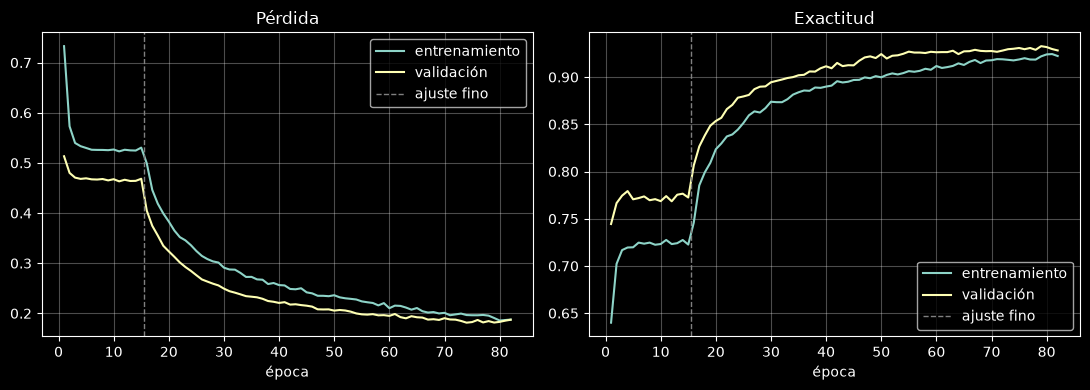

In [37]:
h = historia
epocas = range(1, len(h["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (metrica, titulo) in zip(axes, [("loss", "Pérdida"), ("accuracy", "Exactitud")]):
    ax.plot(epocas, h[metrica], label="entrenamiento")
    ax.plot(epocas, h["val_" + metrica], label="validación")
    ax.set_xlabel("época")
    ax.set_title(titulo)
    ax.axvline(CORTE_ETAPAS + 0.5, color="gray", ls="--", lw=1, label="ajuste fino")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

La distancia entre ambas curvas indica el grado de sobreajuste. Si la de validación se
despega hacia arriba mientras la de entrenamiento sigue bajando, conviene subir el
`Dropout` o intensificar el aumento de datos.

## 6. Evaluación sobre el conjunto de prueba

El conjunto de prueba no participó del entrenamiento ni de la selección de pesos, así
que es la estimación honesta del desempeño. Se evalúa **`modelo_base`**: el aumento sólo
existe en entrenamiento y no tiene nada que hacer acá.

`test_ds` se armó sin mezclar, así que las predicciones salen en el mismo orden que
`idx_test` y las etiquetas verdaderas se leen directamente de `ETIQUETAS[idx_test]`.


In [38]:
y_prob = modelo_base.predict(test_ds, verbose=0)    # (N, 2): P(fuego), P(humo)
# 0,5 es un umbral provisorio para las tablas por etiqueta; el de la alerta sale de
# validación en 5_cuantizacion.ipynb.
y_pred = (y_prob >= 0.5).astype(np.uint8)
y_true = ETIQUETAS[idx_test]
print(f"{len(y_true)} imágenes evaluadas")

4306 imágenes evaluadas


In [39]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix


def informe(y_t, y_p):
    '''Métricas por etiqueta y por combinación, en texto.

    Sin la fila `samples avg` de sklearn: promedia por imagen, y en las `nada` (ninguna
    etiqueta, ~46 % de la prueba) precisión y recall no están definidas y `zero_division=0`
    las cuenta como 0. Sale ~0,5 aunque la red acierte: acá no mide nada.
    El reporte por combinación es la matriz de confusión de abajo en números, e incluye lo
    que el reporte por etiqueta no muestra: cómo le va a la red en las escenas `nada`.
    '''
    r = classification_report(y_t, y_p, target_names=CLASES, digits=3, zero_division=0)
    print("\n".join(l for l in r.splitlines() if not l.lstrip().startswith("samples")) + "\n")
    print(classification_report(combo(y_t), combo(y_p), labels=range(len(COMBOS)),
                                target_names=COMBOS, digits=3, zero_division=0))


informe(y_true, y_pred)

              precision    recall  f1-score   support

       fuego      0.933     0.880     0.905      1115
        humo      0.911     0.901     0.906      2081

   micro avg      0.918     0.894     0.906      3196
   macro avg      0.922     0.890     0.906      3196
weighted avg      0.919     0.894     0.906      3196

              precision    recall  f1-score   support

        nada      0.921     0.923     0.922      2005
        humo      0.814     0.854     0.833      1186
       fuego      0.665     0.723     0.693       220
  fuego+humo      0.887     0.806     0.844       895

    accuracy                          0.869      4306
   macro avg      0.822     0.826     0.823      4306
weighted avg      0.871     0.869     0.870      4306



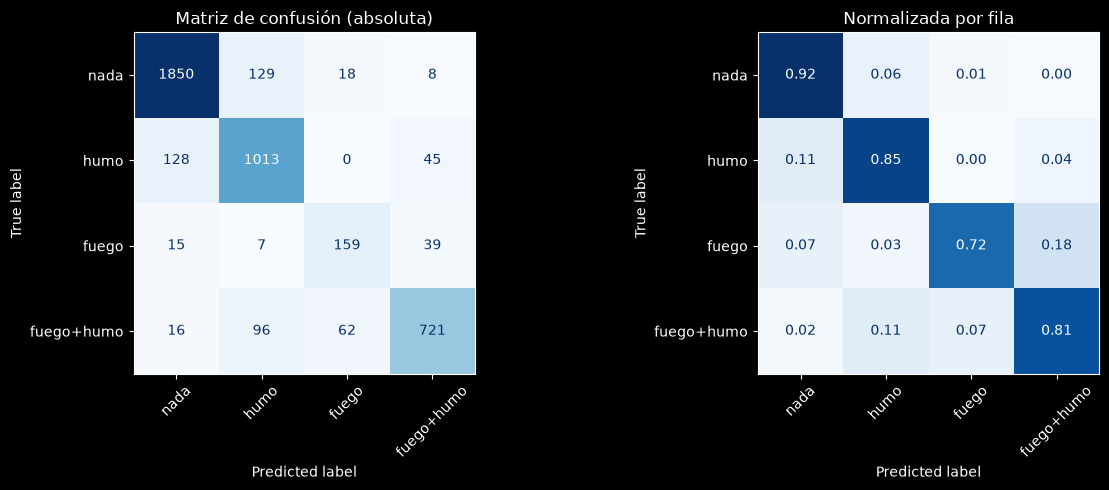

In [40]:
# Matriz sobre las 4 combinaciones: deja ver, por ejemplo, cuántas escenas con fuego y
# humo la red vio sólo como humo.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (norma, formato, titulo) in zip(
    axes,
    [(None, "d", "Matriz de confusión (absoluta)"),
     ("true", ".2f", "Normalizada por fila")],
):
    ConfusionMatrixDisplay(
        confusion_matrix(combo(y_true), combo(y_pred), labels=range(len(COMBOS)),
                         normalize=norma),
        display_labels=COMBOS,
    ).plot(ax=ax, cmap="Blues", colorbar=False, values_format=formato)
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 6bis. Cuánto del conjunto de prueba es un gemelo del entrenamiento

D-Fire sale en buena parte de cuadros de video, y eso deja imágenes casi idénticas
repartidas por todo el banco. Un *dhash* de 64 bits (gradiente horizontal sobre una
miniatura de 9×8 en gris) colapsa a un mismo entero las imágenes visualmente
equivalentes; con 21 527 imágenes la probabilidad de una colisión por azar es del orden
de 10⁻¹¹, así que dos hashes iguales son un gemelo real, no un accidente.

Acertar sobre un gemelo no prueba que la red generalice: prueba que memorizó. La cifra
de abajo dice qué parte del conjunto de prueba está en esa situación, y el informe
siguiente es la métrica honesta: la misma red medida sólo sobre las imágenes de prueba
que **no** tienen gemelo en entrenamiento.


In [41]:
from dfire import sin_gemelo

# `sin_gemelo` compara el dhash de cada imagen de prueba contra todos los de
# entrenamiento (la función está en `modulos/dfire.py`).
LIMPIO = sin_gemelo(ARCHIVOS[idx_train], ARCHIVOS[idx_test])

print(f"prueba: {len(LIMPIO)} imágenes, {np.sum(~LIMPIO)} con gemelo en entrenamiento "
      f"({100 * np.mean(~LIMPIO):.1f} %), {np.sum(LIMPIO)} limpias\n")
print("=== float32, sólo sobre las imágenes de prueba SIN gemelo ===")
informe(y_true[LIMPIO], y_pred[LIMPIO])

prueba: 4306 imágenes, 986 con gemelo en entrenamiento (22.9 %), 3320 limpias

=== float32, sólo sobre las imágenes de prueba SIN gemelo ===
              precision    recall  f1-score   support

       fuego      0.929     0.869     0.898       996
        humo      0.911     0.904     0.907      1756

   micro avg      0.917     0.891     0.904      2752
   macro avg      0.920     0.887     0.903      2752
weighted avg      0.918     0.891     0.904      2752

              precision    recall  f1-score   support

        nada      0.908     0.911     0.909      1394
        humo      0.796     0.846     0.820       930
       fuego      0.620     0.653     0.636       170
  fuego+humo      0.880     0.803     0.840       826

    accuracy                          0.853      3320
   macro avg      0.801     0.803     0.801      3320
weighted avg      0.855     0.853     0.853      3320



El error más costoso es una escena con fuego en la que **ninguna** de las dos salidas se
enciende: el sistema no dispara la alerta. Que la red vea un incendio sólo como humo es
mucho menos grave —la alerta sale igual, y el humo suele anteceder a la llama—.

Por eso la métrica que decide no es la exactitud ni el recall de una etiqueta suelta,
sino qué pasa con la alerta, y el umbral de decisión se fija sobre el modelo **int8**
(notebook 5), que es el que corre en el nodo.

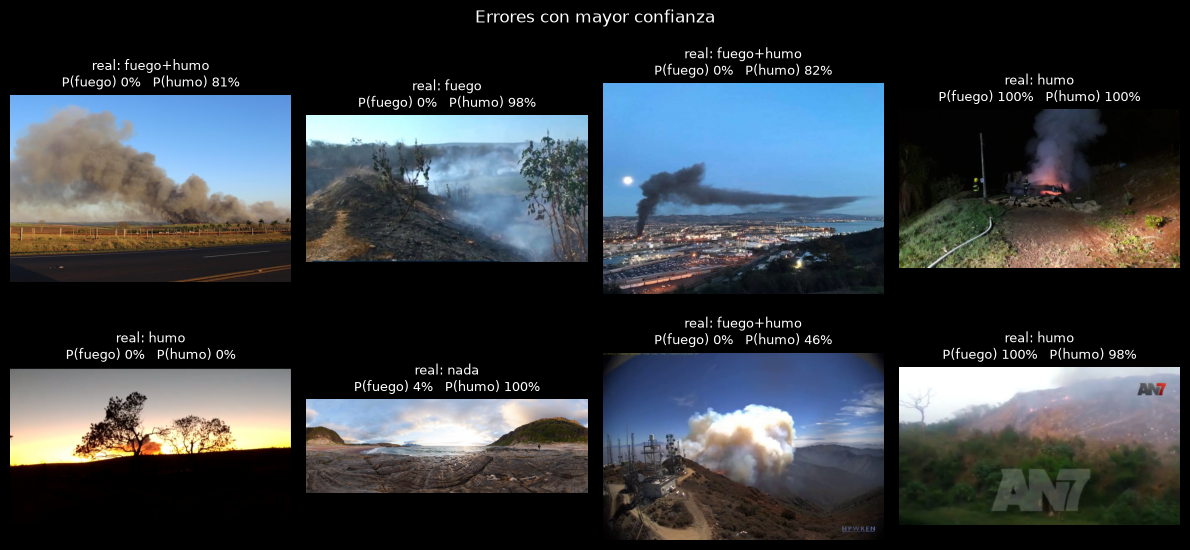

In [42]:
# Peores errores: imágenes con alguna etiqueta mal donde la red más se alejó de la
# verdad (|etiqueta real - probabilidad| en la peor de las dos).
distancia = np.abs(y_true - y_prob).max(axis=1)
errores = np.flatnonzero((y_true != y_pred).any(axis=1))
peores = errores[np.argsort(-distancia[errores])][:8]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.ravel(), peores):
    ax.imshow(keras.utils.load_img(ARCHIVOS[idx_test][idx]))
    ax.set_title(
        f"real: {COMBOS[combo(y_true[idx])]}\n"
        f"P(fuego) {y_prob[idx, 0]:.0%}   P(humo) {y_prob[idx, 1]:.0%}",
        fontsize=9,
    )
    ax.axis("off")
for ax in axes.ravel()[len(peores):]:
    ax.axis("off")
plt.suptitle("Errores con mayor confianza")
plt.tight_layout()
plt.show()

### Fallos de fuego según el tamaño de la llama

La etiqueta `fuego` vale 1 si la imagen trae **al menos una caja** de fuego, sin importar
su tamaño. Llevadas a 96×96, en ~15 % de esas imágenes la caja más grande mide menos de
5 px de lado (mediana ~11 px; la del humo, ~40 px): ahí no queda llama visible que
aprender. Si el recall de fuego se cae sólo en las cajas chicas, esos fallos son ruido de
etiqueta del banco y no un defecto de la red; la columna de alerta dice si el sistema los
rescata igual por el humo.

In [33]:
def lado_fuego_px(ruta_img):
    '''Lado equivalente (raíz del área) de la caja de fuego más grande, en px a 96×96.

    Las coordenadas YOLO van normalizadas a [0, 1] y la imagen se estira a IMG_SIZE, así
    que w·h·96² es el área en píxeles que ve la red. 0 si no hay caja de fuego.
    '''
    ruta = Path(ruta_img)
    txt = ruta.parent.parent / "labels" / (ruta.stem + ".txt")
    cajas = (l.split() for l in txt.read_text().splitlines() if l.split())
    areas = [float(w) * float(h) for c, _, _, w, h in cajas if c == "1"]
    return np.sqrt(max(areas, default=0.0)) * IMG_SIZE[0]


con_fuego = np.flatnonzero(y_true[:, 0] == 1)
lado = np.array([lado_fuego_px(ARCHIVOS[idx_test][i]) for i in con_fuego])
vio_fuego = y_pred[con_fuego, 0] == 1
alerta = y_pred[con_fuego].any(axis=1)      # fuego o humo: la alerta sale igual

print(f"{len(con_fuego)} imágenes de prueba con fuego, umbral provisorio 0,5\n")
print(f"{'lado de la caja':<17}{'imágenes':>9}{'recall fuego':>14}{'con alerta':>12}")
for lo, hi in [(0, 5), (5, 8), (8, 16), (16, 32), (32, np.inf)]:
    m = (lado >= lo) & (lado < hi)
    rango = f"{lo}–{hi:.0f} px" if np.isfinite(hi) else f"≥ {lo} px"
    print(f"{rango:<17}{m.sum():>9}{vio_fuego[m].mean():>14.1%}{alerta[m].mean():>12.1%}")

1115 imágenes de prueba con fuego, umbral provisorio 0,5

lado de la caja   imágenes  recall fuego  con alerta
0–5 px                 179         60.3%       91.6%
5–8 px                 178         92.7%       97.8%
8–16 px                348         92.8%       98.3%
16–32 px               270         95.2%       99.3%
≥ 32 px                140         91.4%       97.1%


## 7. Interpretabilidad: Grad-CAM

Una exactitud alta no garantiza que la red mire lo correcto: podría estar aprovechando
artefactos de adquisición correlacionados con la clase. **Grad-CAM** produce un mapa de
calor de las regiones que más pesaron en la decisión, en tres pasos:

1. Calcular el gradiente de la probabilidad de **una etiqueta** respecto de los mapas de características
   de la última capa convolucional.
2. Promediar ese gradiente sobre el espacio: da un peso por canal, que mide cuánto
   contribuye ese canal a la etiqueta.
3. Sumar los mapas ponderados por esos pesos y quedarse con la parte positiva (ReLU),
   que es la evidencia a favor de la etiqueta.

Con dos sigmoides no hay una "clase predicha" que explicar: una escena puede tener
fuego y humo a la vez, así que se pide un mapa **por etiqueta**.

In [34]:
CAPA_GRAD_CAM = "conv_pw_11_relu"   # grilla de 6×6 a 96×96; la última (conv_pw_13) da 3×3 y no se lee


def grad_cam(modelo, imagen, etiqueta):
    '''Mapa de calor Grad-CAM de UNA etiqueta (índice en CLASES) para una imagen
    (H, W, 3) cruda, en 0-255.

    La etiqueta va explícita: elegirla con `argmax`, como en multiclase, muestra una sola
    en `fuego+humo` y en `nada` dibuja la evidencia de una etiqueta que no está.

    MobileNet va anidada dentro de `modelo_base`, así que su grafo interno no cuelga de
    la entrada del modelo: el submodelo se arma sobre el backbone y se le vuelve a colgar
    la cabeza reutilizando las MISMAS capas (`dropout` y `salida`), o sea los pesos
    entrenados. `GlobalAveragePooling2D` no tiene pesos, se puede crear de nuevo.

    La cabeza cuelga de `backbone.output`, NO de los mapas elegidos: el backbone corre
    entero y la `Dense` de salida recibe los 256 canales que espera. Los mapas
    intermedios salen como una segunda salida del mismo submodelo. Hacerlo al revés
    —colgar la cabeza de los mapas— sólo funciona si la capa elegida es la última, y
    revienta con cualquier otra (`conv_pw_11_relu` da 128 canales, no 256).
    '''
    backbone = modelo.get_layer("mobilenet")
    mapas = backbone.get_layer(CAPA_GRAD_CAM).output
    x = layers.GlobalAveragePooling2D(name="gap_cam")(backbone.output)
    x = modelo.get_layer("dropout")(x, training=False)
    puntajes = modelo.get_layer("salida")(x)
    submodelo = keras.Model(backbone.input, [mapas, puntajes])

    # Misma escala que la capa `Rescaling` del modelo: (pixel / 127.5) - 1.
    x = tf.expand_dims(imagen / 127.5 - 1.0, 0)

    with tf.GradientTape() as cinta:
        mapas_act, predicciones = submodelo(x, training=False)
        score = predicciones[:, etiqueta]

    # d(score)/d(mapas): cuánto cambia la probabilidad de la etiqueta por unidad de activación
    gradientes = cinta.gradient(score, mapas_act)
    pesos = tf.reduce_mean(gradientes, axis=(0, 1, 2))          # promedio espacial
    mapa = tf.reduce_sum(mapas_act[0] * pesos, axis=-1)         # combinación ponderada
    mapa = tf.nn.relu(mapa)                                     # sólo evidencia positiva

    mapa = mapa / (tf.reduce_max(mapa) + keras.backend.epsilon())
    return mapa.numpy()

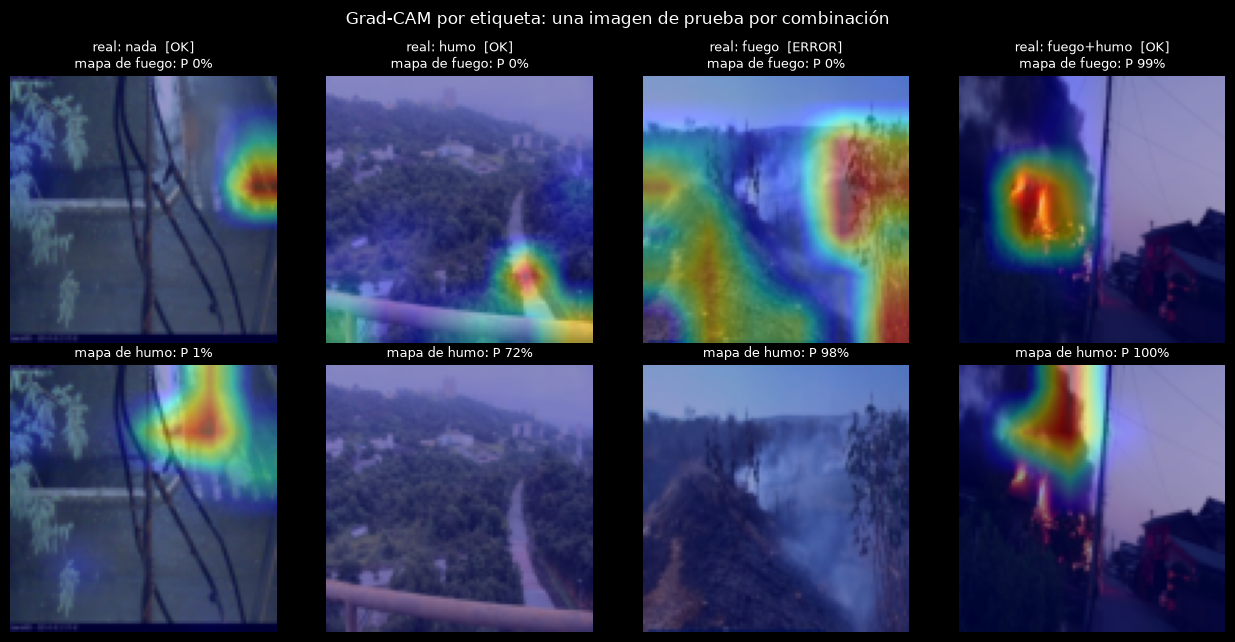

In [35]:
from dfire import leer_imagen

# Una imagen de prueba por combinación y un mapa por etiqueta: en `fuego+humo` tienen que
# encenderse los dos. Cada mapa se normaliza a su máximo, así que siempre hay una zona
# "caliente": si la P del título es baja (p. ej. en `nada`), el mapa no significa nada.
muestras = [np.flatnonzero(combo(y_true) == c)[0] for c in range(len(COMBOS))]

fig, axes = plt.subplots(len(CLASES), len(muestras), figsize=(3.2 * len(muestras), 6.5))
for col, i in enumerate(muestras):
    # Mismo preprocesamiento que test_ds; y_prob está en el orden de idx_test.
    imagen = tf.cast(leer_imagen(ARCHIVOS[idx_test][i]), tf.float32)
    correcto = "OK" if combo(y_pred[i]) == combo(y_true[i]) else "ERROR"
    for fila, nombre in enumerate(CLASES):
        mapa = grad_cam(modelo_base, imagen, fila)
        # El mapa es de 6x6 (resolución de conv_pw_11, 96/16); lo estiramos a la imagen.
        mapa_grande = tf.image.resize(mapa[..., None], IMG_SIZE).numpy().squeeze()
        ax = axes[fila, col]
        ax.imshow(imagen.numpy().astype("uint8"))
        ax.imshow(mapa_grande, cmap="jet", alpha=0.4)
        cabecera = f"real: {COMBOS[combo(y_true[i])]}  [{correcto}]\n" if fila == 0 else ""
        ax.set_title(f"{cabecera}mapa de {nombre}: P {y_prob[i, fila]:.0%}", fontsize=9)
        ax.axis("off")

plt.suptitle("Grad-CAM por etiqueta: una imagen de prueba por combinación")
plt.tight_layout()
plt.show()

Si las zonas calientes coinciden con llamas o penachos de humo, la red aprendió
las características relevantes. Si se concentran en el cielo, los bordes o regiones
fijas del cuadro, está explotando atajos del dataset y el resultado no generalizaría
a las cámaras del nodo LoRa.

## 8. Entregable: el modelo entrenado

La salida de este notebook es el **`.keras` en float32**: el *checkpoint* de
`modelo_base`, el modelo sin las capas de aumento. No va al nodo tal cual:
`5_cuantizacion.ipynb` lo toma, lo cuantiza a int8, lo mide como lo va a ver la cámara,
fija el umbral de decisión y genera los archivos para el firmware.

| Archivo | Qué es |
|---|---|
| `salidas/modelos/cnn_fuego_epochs_*_image_size_96x96.keras` | modelo entrenado; el notebook 5 toma el más reciente |

In [ ]:
# `EPOCAS_REALES`, no el tope: EarlyStopping corta antes y el nombre tiene que decir
# cuántas épocas se entrenaron de verdad.
ruta_modelos = SALIDAS / "modelos"
ruta_modelos.mkdir(parents=True, exist_ok=True)
ruta_keras = ruta_modelos / f"cnn_fuego_epochs_{EPOCAS_REALES}_image_size_{IMG_SIZE[0]}x{IMG_SIZE[1]}.keras"
modelo_base.save(ruta_keras)
print(f"{ruta_keras}  ({ruta_keras.stat().st_size / 1024:.0f} kB)")

## 9. Conclusiones y posibles extensiones

Lo construido: un detector multi-etiqueta —P(fuego) y P(humo), independientes— entrenado sobre D-Fire, con el pipeline
completo de datos, entrenamiento regularizado, evaluación sobre un conjunto reservado
e inspección de lo que la red aprendió (Grad-CAM). La cuantización a **TFLite Micro
int8** para el ESP32-S3, y todo lo que mide al modelo tal como corre en el nodo, están
en `5_cuantizacion.ipynb`. Es el eslabón de visión del Proyecto Final (red LoRa de detección
temprana de incendios): queda validado que la señal visual alcanza para discriminar *y* que
el modelo entra en el nodo.

Dos resultados condicionan cómo leer los números:

- **Fuego y humo no son excluyentes.** El 80 % de las escenas con llama también tiene
  humo. Con tres clases excluyentes la salida `humo` significaba "humo sin fuego" y la
  probabilidad de humo de un incendio salía cero por construcción; con dos sigmoides cada
  una mide lo suyo, que es lo que necesita el índice de probabilidad del backend.
- **El banco se contamina a sí mismo.** El 22,9 % de las imágenes de prueba tiene un
  gemelo perceptual en entrenamiento (§6bis), aun respetando la partición oficial. Las
  métricas se informan con y sin esos gemelos; la que vale es la segunda.

Limitaciones y direcciones para seguir:

- **Etiquetas a nivel imagen derivadas de cajas.** Colapsar la detección a una sola
  etiqueta por imagen pierde la localización: el modelo dice *si* hay fuego, no
  *dónde*. El paso natural es entrenar un detector (YOLO) sobre las mismas anotaciones.
- **Desbalance.** Casi la mitad del banco es fondo y sólo el 27 % tiene fuego. Acá se
  compensa con el umbral de decisión (notebook 5), porque `class_weight` no sirve con salidas
  multi-etiqueta; si no alcanza, las alternativas son balancear el muestreo o una pérdida
  con peso por etiqueta.
- **Transfer learning.** MobileNetV1 α=0.25 preentrenada en ImageNet ya es el caso base de
  este notebook; con más datos, α=0.5 (796 kB de pesos int8, sigue entrando en SRAM
  interna) es el escalón siguiente.
